# Gym Member Matching Algorithm 💘
## Building a Similarity-Based Matching System for Fitness Partners

In [48]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

## 1. Loading and exploring the data

In [61]:
# Load the synthetic gym member dataset
df = pd.read_csv('synthetic_gym_members_dataset.csv')

print(f"Dataset loaded successfully: {df.shape[0]} members, {df.shape[1]} features")
print(f"\nDataset columns: {list(df.columns)}")

# Display basic statistics
print("\nNumerical feature statistics:")
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(df[numerical_cols].describe())

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Insert my profile as the target member
my_profile = {
    'member_id': 1,
    'name': 'Karl Foster',
    'age': 32,
    'sex': 'Male',
    'training_frequency_per_week': 4,
    'training_type': 'Gym',
    'preferred_time_slot': 'Afternoon',
    'preferred_hour': 17,
    'preferred_days': 'Friday,Monday,Sunday,Thursday',
    'schedule_preference': 'Weekday Focused',
    'tenure_months': 13,
    'freeze_period': None,
    'lifetime_value': 1050.54,
    'fitness_level': 'Intermediate',
    'primary_goal': 'General Fitness',
    'social_preference': 'Solo',
    'experience_level': 'Intermediate',
    'monthly_value': 72.0,
}

df.iloc[0] = my_profile
print(f"\nTarget member profile inserted: {my_profile['name']}")
df.head()

Dataset loaded successfully: 10000 members, 18 features

Dataset columns: ['member_id', 'name', 'age', 'sex', 'training_frequency_per_week', 'training_type', 'preferred_time_slot', 'preferred_hour', 'preferred_days', 'schedule_preference', 'tenure_months', 'freeze_period', 'lifetime_value', 'fitness_level', 'primary_goal', 'social_preference', 'experience_level', 'monthly_value']

Numerical feature statistics:
         member_id           age  training_frequency_per_week  preferred_hour  \
count  10000.00000  10000.000000                 10000.000000    10000.000000   
mean    5000.50000     31.624200                     2.400600       14.125800   
std     2886.89568      7.691547                     1.420113        5.173089   
min        1.00000     18.000000                     1.000000        0.000000   
25%     2500.75000     26.000000                     1.000000       10.000000   
50%     5000.50000     31.000000                     2.000000       15.000000   
75%     7500.25000 

,member_id,name,age,sex,training_frequency_per_week,training_type,preferred_time_slot,preferred_hour,preferred_days,schedule_preference,tenure_months,freeze_period,lifetime_value,fitness_level,primary_goal,social_preference,experience_level,monthly_value
0,1,Karl Foster,32,Male,4,Gym,Afternoon,17,"Friday,Monday,Sunday,Thursday",Weekday Focused,13,NaN,1050.54,Intermediate,General Fitness,Solo,Intermediate,72.0
1,3,Koreem,31,Male,5,Gym,Evening,21,"Friday,Monday,Saturday,Thursday,Wednesday",Weekday Focused,33,NaN,2149.72,Advanced,Muscle Gain,Large Group,Experienced,70.0
2,9,Anfernee,37,Male,6,Gym,Evening,20,"Friday,Monday,Saturday,Sunday,Thursday,Tuesday",Weekday Focused,3,NaN,211.02,Intermediate,General Fitness,Solo,Novice,70.0
3,12,Dontay,35,Male,3,Cycling,Evening,19,"Monday,Sunday,Thursday",Weekday Focused,18,NaN,1261.99,Intermediate,General Fitness,Small Group,Intermediate,72.0
4,13,Welborn,24,Male,3,Gym,Evening,19,"Sunday,Thursday,Wednesday",Weekday Focused,1,NaN,71.13,Advanced,Weight Loss,Solo,Novice,60.0


## 2. EDA

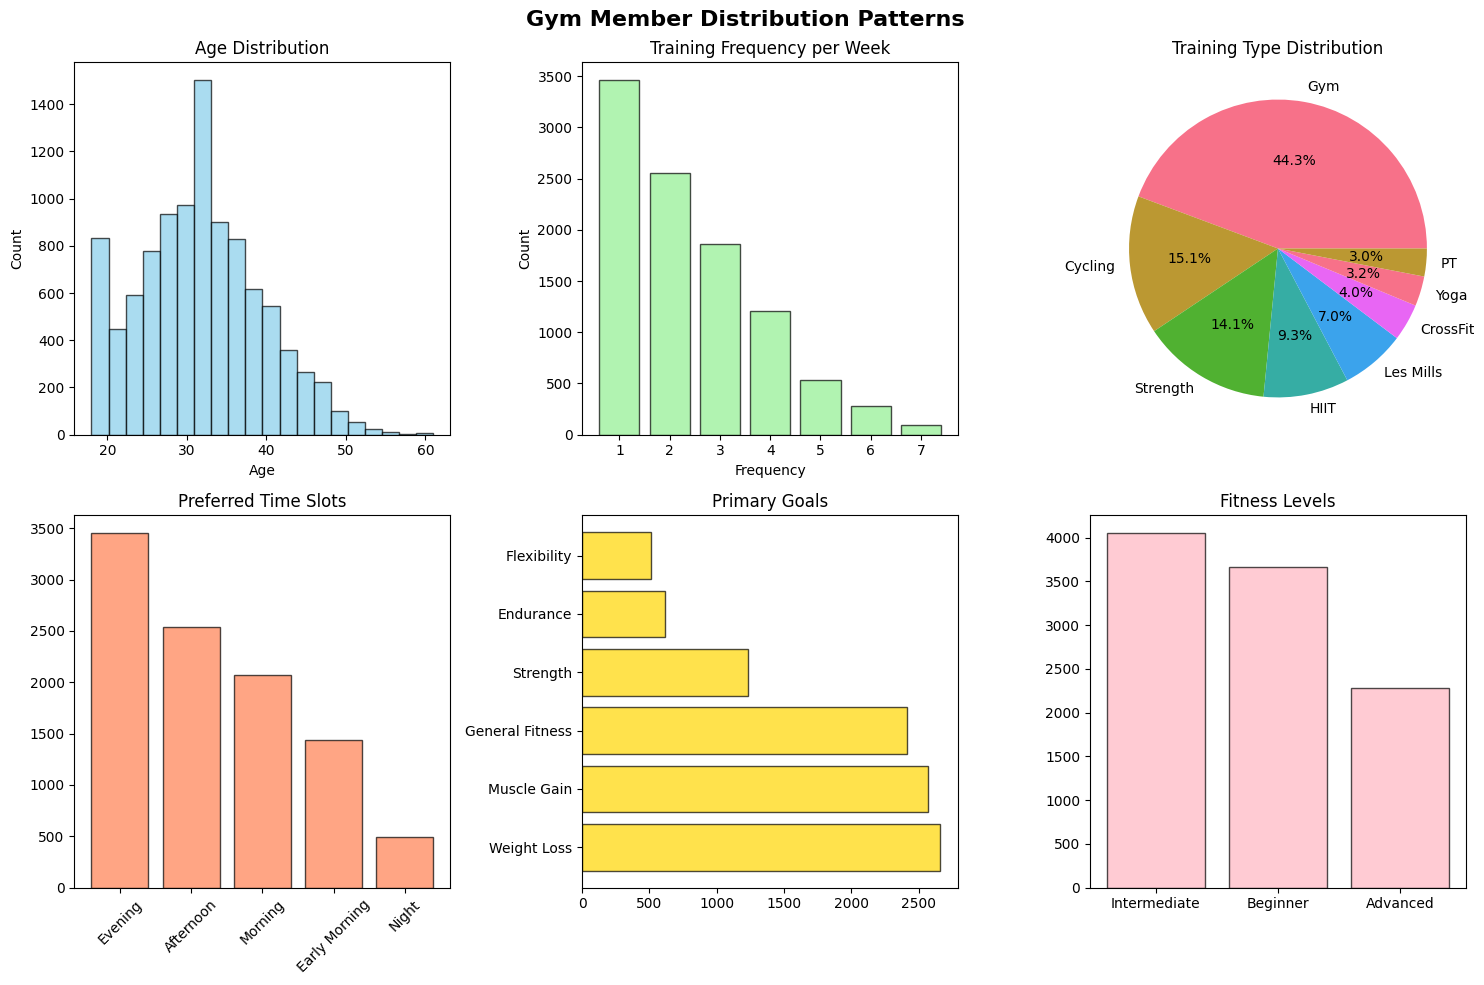

In [50]:
def create_distribution_plots(df):
    """
    Generate comprehensive visualizations of gym member patterns
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Gym Member Distribution Patterns', fontsize=16, fontweight='bold')
    
    # Age distribution
    axes[0,0].hist(df['age'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].set_title('Age Distribution')
    axes[0,0].set_xlabel('Age')
    axes[0,0].set_ylabel('Count')
    
    # Training frequency
    freq_counts = df['training_frequency_per_week'].value_counts().sort_index()
    axes[0,1].bar(freq_counts.index, freq_counts.values, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0,1].set_title('Training Frequency per Week')
    axes[0,1].set_xlabel('Frequency')
    axes[0,1].set_ylabel('Count')
    
    # Training type distribution
    training_counts = df['training_type'].value_counts()
    axes[0,2].pie(training_counts.values, labels=training_counts.index, autopct='%1.1f%%')
    axes[0,2].set_title('Training Type Distribution')
    
    # Time slot preferences
    time_counts = df['preferred_time_slot'].value_counts()
    axes[1,0].bar(time_counts.index, time_counts.values, alpha=0.7, color='coral', edgecolor='black')
    axes[1,0].set_title('Preferred Time Slots')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Goals distribution
    goal_counts = df['primary_goal'].value_counts()
    axes[1,1].barh(goal_counts.index, goal_counts.values, alpha=0.7, color='gold', edgecolor='black')
    axes[1,1].set_title('Primary Goals')
    
    # Fitness level distribution
    level_counts = df['fitness_level'].value_counts()
    axes[1,2].bar(level_counts.index, level_counts.values, alpha=0.7, color='lightpink', edgecolor='black')
    axes[1,2].set_title('Fitness Levels')
    
    plt.tight_layout()
    plt.show()

create_distribution_plots(df)


## 3. Prepocessing

In [51]:
def encode_categorical_features(df):
    """
    Convert categorical variables to numerical format using Label Encoding.
    
    Why this matters:
    - Machine learning algorithms require numerical input
    - Distance calculations need consistent data types
    - We exclude 'sex' to use it for post-matching filtering
    """
    encoded_df = df.copy()
    label_encoders = {}
    
    # Identify categorical columns (excluding ID and sex)
    categorical_columns = [col for col in df.columns 
                          if df[col].dtype == 'object' and col not in ['member_id', 'sex']]
    
    print(f"Encoding categorical features: {categorical_columns}")
    
    for col in categorical_columns:
        le = LabelEncoder()
        encoded_df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
    
    return encoded_df, label_encoders

def handle_circular_time_features(encoded_df):
    """
    Convert time-based features to circular representation.
    
    Why circular encoding:
    - 23:00 (11 PM) should be "close" to 06:00 (6 AM) in time
    - Linear encoding would treat them as far apart (23 vs 6)
    - Sin/Cos transformation preserves circular nature of time
    """
    if 'preferred_hour' in encoded_df.columns:
        print("Converting preferred_hour to circular features...")
        
        # Convert to radians (0-24 hours -> 0-2π)
        hour_radians = 2 * np.pi * encoded_df['preferred_hour'] / 24
        
        # Create sine and cosine components
        encoded_df['hour_sin'] = np.sin(hour_radians)
        encoded_df['hour_cos'] = np.cos(hour_radians)
        
        print("Added circular time features: hour_sin, hour_cos")
    
    return encoded_df

def prepare_feature_matrix(encoded_df, exclude_financial=True):
    """
    Select and prepare features for similarity calculation.
    
    Why we exclude financial data:
    - Focus on fitness compatibility rather than economic factors
    - Monthly/lifetime value shouldn't determine workout partners
    """
    excluded_cols = ['member_id', 'sex']
    if exclude_financial:
        excluded_cols.extend(['monthly_value', 'lifetime_value'])
    
    # Select numerical columns for distance calculation
    numerical_cols = [col for col in encoded_df.columns 
                     if encoded_df[col].dtype in ['int64', 'float64'] 
                     and col not in excluded_cols]
    
    print(f"Features selected for matching: {numerical_cols}")
    
    feature_matrix = encoded_df[numerical_cols].fillna(0)
    
    return feature_matrix, numerical_cols

# Apply preprocessing steps
encoded_df, label_encoders = encode_categorical_features(df)
encoded_df = handle_circular_time_features(encoded_df)
feature_matrix, feature_names = prepare_feature_matrix(encoded_df)

print(f"\nFeature matrix shape: {feature_matrix.shape}")

Encoding categorical features: ['name', 'training_type', 'preferred_time_slot', 'preferred_days', 'schedule_preference', 'fitness_level', 'primary_goal', 'social_preference', 'experience_level']
Converting preferred_hour to circular features...
Added circular time features: hour_sin, hour_cos
Features selected for matching: ['age', 'training_frequency_per_week', 'preferred_hour', 'tenure_months', 'freeze_period', 'name_encoded', 'training_type_encoded', 'preferred_time_slot_encoded', 'preferred_days_encoded', 'schedule_preference_encoded', 'fitness_level_encoded', 'primary_goal_encoded', 'social_preference_encoded', 'experience_level_encoded', 'hour_sin', 'hour_cos']

Feature matrix shape: (10000, 16)


## 4. Feature scaling

In [52]:
def scale_features(feature_matrix):
    """
    Standardize features to ensure equal importance in distance calculation.
    
    Why standardization is crucial:
    - Features have different scales (age: 18-60, frequency: 1-7)
    - Without scaling, high-value features dominate the distance
    - StandardScaler transforms to mean=0, std=1
    """
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(feature_matrix)
    
    print("Features standardized (mean=0, std=1)")
    print(f"Original feature ranges: {feature_matrix.min().min():.2f} to {feature_matrix.max().max():.2f}")
    print(f"Scaled feature ranges: {scaled_features.min():.2f} to {scaled_features.max():.2f}")
    
    return scaled_features, scaler

def calculate_member_distances(scaled_features):
    """
    Compute pairwise Euclidean distances between all members.
    
    Euclidean distance formula:
    d = √[(x₁-x₂)² + (y₁-y₂)² + ... + (n₁-n₂)²]
    
    Why Euclidean distance:
    - Intuitive measure of similarity in multi-dimensional space
    - Smaller distance = more similar members
    - Works well with standardized features
    """
    distance_matrix = euclidean_distances(scaled_features)
    
    print(f"Distance matrix computed: {distance_matrix.shape}")
    print(f"Distance range: {distance_matrix.min():.3f} to {distance_matrix.max():.3f}")
    
    return distance_matrix

# Apply scaling and calculate distances
scaled_features, scaler = scale_features(feature_matrix)
distance_matrix = calculate_member_distances(scaled_features)


Features standardized (mean=0, std=1)
Original feature ranges: -1.00 to 9999.00
Scaled feature ranges: -2.73 to 5.82
Distance matrix computed: (10000, 10000)
Distance range: 0.000 to 11.409


## 5. Member matching algo

In [53]:
def find_compatible_matches(df, distance_matrix, target_member_id=1, 
                           gender_filter='Female', num_matches=5):
    """
    Find the most compatible gym members based on fitness preferences.
    
    Algorithm:
    1. Get target member's distance vector
    2. Filter by desired gender
    3. Sort by similarity (lowest distance)
    4. Return top matches with detailed comparison
    """
    print(f"Finding matches for Member ID: {target_member_id}")
    print(f"Gender filter: {gender_filter} members only")
    print(f"Requested matches: {num_matches}")
    
    # Get target member information
    target_idx = df[df['member_id'] == target_member_id].index[0]
    target_info = df.iloc[target_idx]
    
    # Extract distances from target to all other members
    target_distances = distance_matrix[target_idx]
    
    # Create candidate list with gender filtering
    candidates = []
    for idx, distance in enumerate(target_distances):
        if idx != target_idx:  # Exclude self
            member_info = df.iloc[idx]
            if member_info['sex'] == gender_filter:
                candidates.append((idx, distance, member_info))
    
    # Sort by distance (similarity)
    candidates.sort(key=lambda x: x[1])
    top_matches = candidates[:num_matches]
    
    print(f"Found {len(candidates)} total {gender_filter.lower()} candidates")
    print(f"Returning top {len(top_matches)} matches")
    
    return top_matches, target_info

def create_match_comparison_table(top_matches, target_info):
    """
    Generate a detailed comparison table of matching results.
    """
    comparison_data = []
    
    # Add target member as reference
    comparison_data.append({
        'Rank': 'TARGET',
        'Name': target_info['name'],
        'Age': target_info['age'],
        'Training_Freq': target_info['training_frequency_per_week'],
        'Training_Type': target_info['training_type'],
        'Time_Slot': target_info['preferred_time_slot'],
        'Hour': target_info['preferred_hour'],
        'Days': target_info['preferred_days'][:25] + '...' 
                if len(str(target_info['preferred_days'])) > 25 
                else target_info['preferred_days'],
        'Fitness_Level': target_info['fitness_level'],
        'Goal': target_info['primary_goal'],
        'Social_Pref': target_info['social_preference'],
        'Experience': target_info['experience_level'],
        'Tenure': target_info['tenure_months'],
        'Distance': 0.000,
        'Similarity': 1.000
    })
    
    # Add matched members
    for rank, (member_idx, distance, member_info) in enumerate(top_matches, 1):
        similarity_score = 1 / (1 + distance)  # Convert distance to similarity
        
        comparison_data.append({
            'Rank': rank,
            'Name': member_info['name'],
            'Age': member_info['age'],
            'Training_Freq': member_info['training_frequency_per_week'],
            'Training_Type': member_info['training_type'],
            'Time_Slot': member_info['preferred_time_slot'],
            'Hour': member_info['preferred_hour'],
            'Days': member_info['preferred_days'][:25] + '...' 
                    if len(str(member_info['preferred_days'])) > 25 
                    else member_info['preferred_days'],
            'Fitness_Level': member_info['fitness_level'],
            'Goal': member_info['primary_goal'],
            'Social_Pref': member_info['social_preference'],
            'Experience': member_info['experience_level'],
            'Tenure': member_info['tenure_months'],
            'Distance': round(distance, 3),
            'Similarity': round(similarity_score, 3)
        })
    
    return pd.DataFrame(comparison_data)

## 6. Run the matchmaker

In [54]:
# Find female matches for Karl Foster
matches, target_info = find_compatible_matches(
    df=df, 
    distance_matrix=distance_matrix, 
    target_member_id=1, 
    gender_filter='Female', 
    num_matches=5
)

# Create detailed comparison table
results_df = create_match_comparison_table(matches, target_info)

print("\n" + "="*80)
print("MEMBER MATCHING RESULTS")
print("="*80)
print(f"\nTarget Member: {target_info['name']}")
print(f"Matching Criteria: Female gym members with similar fitness preferences")
print(f"Algorithm: Euclidean distance on standardized features")

print(f"\nDETAILED COMPARISON:")
print("-" * 80)

# Display results with proper formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 25)

print(results_df.to_string(index=False))

# Reset display options
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')


Finding matches for Member ID: 1
Gender filter: Female members only
Requested matches: 5
Found 5239 total female candidates
Returning top 5 matches

MEMBER MATCHING RESULTS

Target Member: Karl Foster
Matching Criteria: Female gym members with similar fitness preferences
Algorithm: Euclidean distance on standardized features

DETAILED COMPARISON:
--------------------------------------------------------------------------------
  Rank        Name  Age  Training_Freq Training_Type Time_Slot  Hour                         Days Fitness_Level            Goal Social_Pref   Experience  Tenure  Distance  Similarity
TARGET Karl Foster   32              4           Gym Afternoon    17 Friday,Monday,Sunday,Thur...  Intermediate General Fitness        Solo Intermediate      13     0.000       1.000
     1   Ekaterini   33              4           Gym Afternoon    17 Friday,Monday,Sunday,Thur...  Intermediate General Fitness        Solo Intermediate      12     0.719       0.582
     2      Eumeka   

## 7. Analysis

In [55]:
print(f"\n" + "="*80)
print("ALGORITHM INSIGHTS")
print("="*80)

print(f"\nTop Match Analysis:")
if len(matches) > 0:
    best_match = matches[0]
    best_member = best_match[2]
    best_distance = best_match[1]
    
    print(f"• Best match: {best_member['name']} (Distance: {best_distance:.3f})")
    print(f"• Shared attributes:")
    print(f"  - Similar age: {target_info['age']} vs {best_member['age']}")
    print(f"  - Training frequency: {target_info['training_frequency_per_week']} vs {best_member['training_frequency_per_week']} times/week")
    print(f"  - Preferred time: {target_info['preferred_time_slot']} vs {best_member['preferred_time_slot']}")
    print(f"  - Fitness level: {target_info['fitness_level']} vs {best_member['fitness_level']}")
    print(f"  - Primary goal: {target_info['primary_goal']} vs {best_member['primary_goal']}")
    print(f"  - Social preference: {target_info['social_preference']} vs {best_member['social_preference']}")
    print(f"  - Experience level: {target_info['experience_level']} vs {best_member['experience_level']}")
    print(f"  - Tenure: {target_info['tenure_months']} vs {best_member['tenure_months']} months")
    print(f"  - Days: {target_info['preferred_days']} vs {best_member['preferred_days']}")

print(f"\nDistance Distribution of Female Matches:")
female_distances = [match[1] for match in matches]
print(f"• Mean distance: {np.mean(female_distances):.3f}")
print(f"• Distance range: {min(female_distances):.3f} - {max(female_distances):.3f}")
print(f"• This suggests {'high' if np.mean(female_distances) < 2 else 'moderate'} compatibility in the dataset")

# Final output
print(f"\n🎯 Ready to find your gym soulmate!")
print(f"💪 Algorithm successfully identified {len(matches)} compatible female members")



ALGORITHM INSIGHTS

Top Match Analysis:
• Best match: Ekaterini (Distance: 0.719)
• Shared attributes:
  - Similar age: 32 vs 33
  - Training frequency: 4 vs 4 times/week
  - Preferred time: Afternoon vs Afternoon
  - Fitness level: Intermediate vs Intermediate
  - Primary goal: General Fitness vs General Fitness
  - Social preference: Solo vs Solo
  - Experience level: Intermediate vs Intermediate
  - Tenure: 13 vs 12 months
  - Days: Friday,Monday,Sunday,Thursday vs Friday,Monday,Sunday,Thursday

Distance Distribution of Female Matches:
• Mean distance: 1.366
• Distance range: 0.719 - 1.823
• This suggests high compatibility in the dataset

🎯 Ready to find your gym soulmate!
💪 Algorithm successfully identified 5 compatible female members


## 8. Visualizing distances

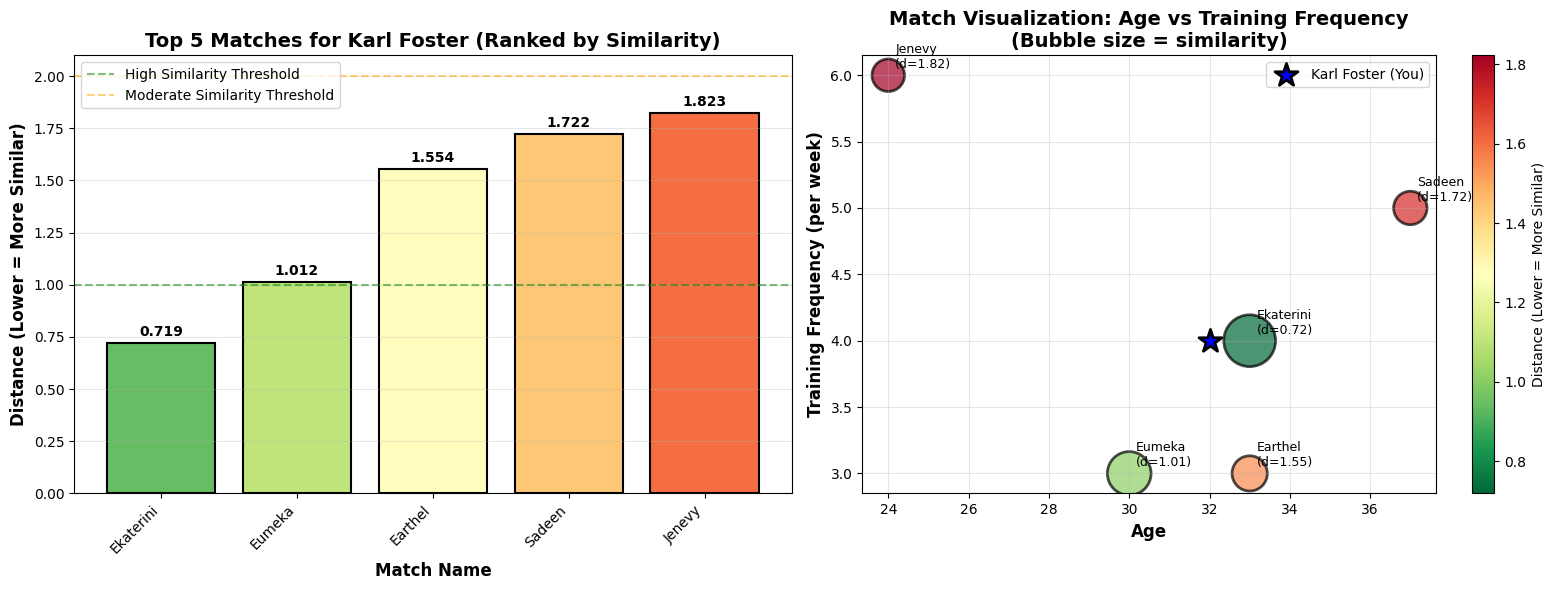

In [56]:
# Create a visualization of the top 5 match distances
def plot_match_distances(matches, target_info):
    """
    Create a visualization showing the distance of top 5 matches from the target member.
    """
    # Extract match data
    names = [match[2]['name'] for match in matches[:5]]
    distances = [match[1] for match in matches[:5]]
    ages = [match[2]['age'] for match in matches[:5]]
    training_freqs = [match[2]['training_frequency_per_week'] for match in matches[:5]]
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Distance Bar Chart
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(names)))
    bars = ax1.bar(range(len(names)), distances, color=colors, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for i, (bar, distance) in enumerate(zip(bars, distances)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{distance:.3f}', ha='center', va='bottom', fontweight='bold')
    
    ax1.set_xticks(range(len(names)))
    ax1.set_xticklabels(names, rotation=45, ha='right')
    ax1.set_xlabel('Match Name', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Distance (Lower = More Similar)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Top 5 Matches for {target_info["name"]} (Ranked by Similarity)', 
                  fontsize=14, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add reference line for "very similar" threshold
    ax1.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='High Similarity Threshold')
    ax1.axhline(y=2.0, color='orange', linestyle='--', alpha=0.5, label='Moderate Similarity Threshold')
    ax1.legend()
    
    # Plot 2: Scatter plot with multiple dimensions
    ax2.scatter(ages, training_freqs, s=[1000/d for d in distances], 
                c=distances, cmap='RdYlGn_r', edgecolors='black', linewidth=2, alpha=0.7)
    
    # Add target member as reference point
    ax2.scatter(target_info['age'], target_info['training_frequency_per_week'], 
                s=300, c='blue', marker='*', edgecolors='black', linewidth=2, 
                label=f'{target_info["name"]} (You)', zorder=5)
    
    # Add labels for each match
    for i, (age, freq, name, dist) in enumerate(zip(ages, training_freqs, names, distances)):
        ax2.annotate(f'{name}\n(d={dist:.2f})', (age, freq), 
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    ax2.set_xlabel('Age', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Training Frequency (per week)', fontsize=12, fontweight='bold')
    ax2.set_title('Match Visualization: Age vs Training Frequency\n(Bubble size = similarity)', 
                  fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Add colorbar for distance
    sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=plt.Normalize(vmin=min(distances), vmax=max(distances)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax2)
    cbar.set_label('Distance (Lower = More Similar)', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Generate the visualization
plot_match_distances(matches, target_info)


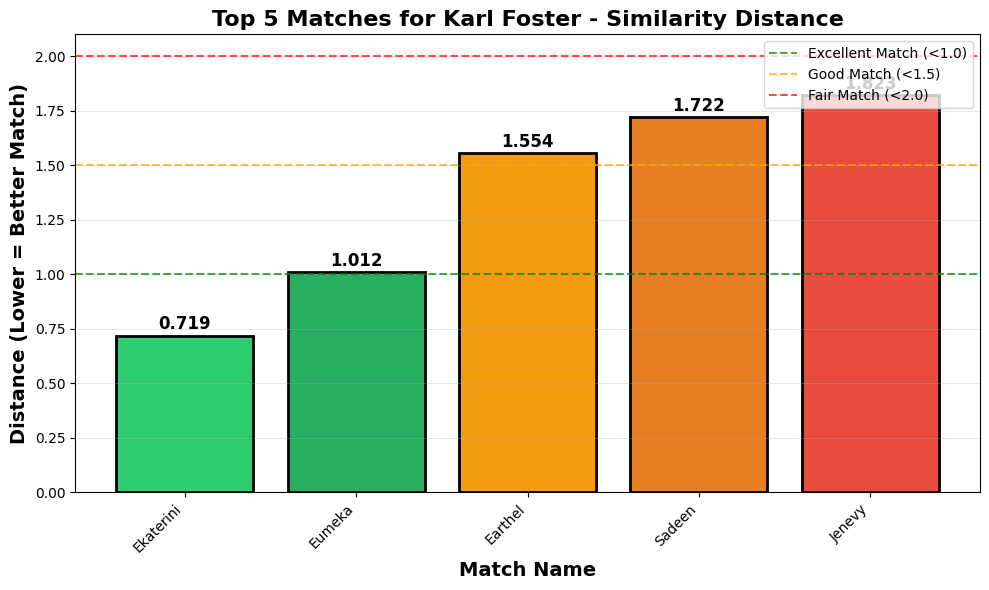


📊 Match Distance Summary:
• Best match: Ekaterini (distance: 0.719)
• Average distance: 1.366
• All 5 matches have fair compatibility!


In [57]:
# Simple bar chart of match distances
def plot_simple_distances(matches, target_info):
    """
    Create a simple bar chart showing match distances.
    """
    # Extract top 5 matches
    top_5_matches = matches[:5]
    names = [match[2]['name'] for match in top_5_matches]
    distances = [match[1] for match in top_5_matches]
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Create bars with color gradient
    colors = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c'][:len(names)]
    bars = plt.bar(names, distances, color=colors, edgecolor='black', linewidth=2)
    
    # Add value labels on bars
    for bar, distance in zip(bars, distances):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{distance:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # Customize the plot
    plt.xlabel('Match Name', fontsize=14, fontweight='bold')
    plt.ylabel('Distance (Lower = Better Match)', fontsize=14, fontweight='bold')
    plt.title(f'Top 5 Matches for {target_info["name"]} - Similarity Distance', 
              fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    
    # Add grid and threshold lines
    plt.grid(axis='y', alpha=0.3)
    plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.7, label='Excellent Match (<1.0)')
    plt.axhline(y=1.5, color='orange', linestyle='--', alpha=0.7, label='Good Match (<1.5)')
    plt.axhline(y=2.0, color='red', linestyle='--', alpha=0.7, label='Fair Match (<2.0)')
    
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n📊 Match Distance Summary:")
    print(f"• Best match: {names[0]} (distance: {distances[0]:.3f})")
    print(f"• Average distance: {np.mean(distances):.3f}")
    print(f"• All 5 matches have {'excellent' if max(distances) < 1.0 else 'good' if max(distances) < 1.5 else 'fair'} compatibility!")

# Generate the simple visualization
plot_simple_distances(matches, target_info)
